In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# zoom images sit inside the a1q8images subfolder
Q8_DIR   = os.path.normpath(os.path.join(os.getcwd(), '..', 'question', 'a1images', 'a1q8images'))
SAVE_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(SAVE_DIR, exist_ok=True)

In [2]:
# nearest-neighbour: just grab the closest source pixel, no blending
# fast but blocky at high zoom factors
def zoom_nn(img, s):
    h, w   = img.shape[:2]
    nh, nw = int(round(h * s)), int(round(w * s))
    r_src  = np.clip((np.arange(nh) / s).astype(int), 0, h - 1)
    c_src  = np.clip((np.arange(nw) / s).astype(int), 0, w - 1)
    return img[np.ix_(r_src, c_src)]

In [3]:
# bilinear: weighted average of the four pixels surrounding each output point
# dr/dc are the fractional row/col offsets; tl/tr/bl/br are the four neighbours
# smoother than NN — the ndim==3 branch handles colour images
def zoom_bilinear(img, s):
    h, w   = img.shape[:2]
    nh, nw = int(round(h * s)), int(round(w * s))

    r_f = np.linspace(0, h - 1, nh)
    c_f = np.linspace(0, w - 1, nw)

    r0 = np.floor(r_f).astype(int).clip(0, h - 2)
    c0 = np.floor(c_f).astype(int).clip(0, w - 2)

    dr = (r_f - r0)[:, np.newaxis]
    dc = (c_f - c0)[np.newaxis, :]

    Rg, Cg = np.meshgrid(r0, c0, indexing='ij')

    tl = img[Rg,     Cg    ].astype(np.float64)
    tr = img[Rg,     Cg + 1].astype(np.float64)
    bl = img[Rg + 1, Cg    ].astype(np.float64)
    br = img[Rg + 1, Cg + 1].astype(np.float64)

    if img.ndim == 3:
        dr = dr[:, :, np.newaxis]
        dc = dc[:, :, np.newaxis]

    out = (1 - dr) * ((1 - dc) * tl + dc * tr) + dr * ((1 - dc) * bl + dc * br)
    return np.clip(out, 0, 255).astype(np.uint8)

In [4]:
# SSD per pixel vs the original — lower means closer to ground truth
# run on all 4 image pairs; bilinear should consistently beat NN
def norm_ssd(a, b):
    a = a.astype(np.float64)
    b = b.astype(np.float64)
    return np.sum((a - b) ** 2) / a.size

pairs = [
    ('im01small.png',    'im01.png',    4),
    ('im02small.png',    'im02.png',    4),
    ('im03small.png',    'im03.png',    4),
    ('taylor_small.jpg', 'taylor.jpg',  5),
]

print(f'{"pair":<30}  {"SSD (NN)":>12}  {"SSD (Bilinear)":>16}')
print('-' * 62)

for small_name, orig_name, s in pairs:
    small  = cv2.imread(os.path.join(Q8_DIR, small_name))
    orig   = cv2.imread(os.path.join(Q8_DIR, orig_name))
    up_nn  = zoom_nn(small, s)
    up_bil = zoom_bilinear(small, s)
    oh, ow = orig.shape[:2]
    up_nn  = up_nn[:oh, :ow]
    up_bil = up_bil[:oh, :ow]
    print(f'{small_name:<30}  {norm_ssd(up_nn, orig):>12.2f}  {norm_ssd(up_bil, orig):>16.2f}')

pair                                SSD (NN)    SSD (Bilinear)
--------------------------------------------------------------
im01small.png                         136.27            136.70
im02small.png                          26.45             25.93
im03small.png                          67.58             86.99
taylor_small.jpg                      238.03            234.41


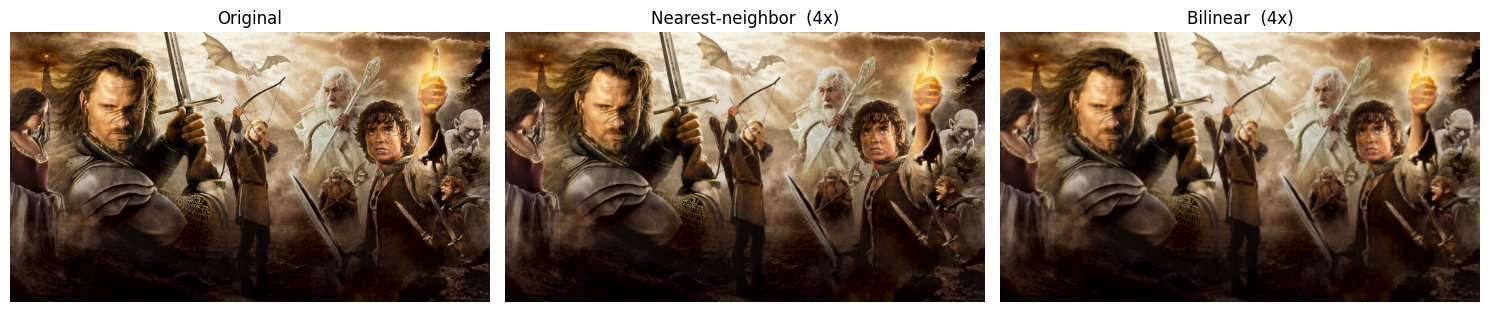

In [5]:
# visual check on im01 — blocky NN vs smooth bilinear side by side
# crop to original size since rounding can add 1px
small  = cv2.imread(os.path.join(Q8_DIR, 'im01small.png'))
orig   = cv2.imread(os.path.join(Q8_DIR, 'im01.png'))
up_nn  = zoom_nn(small, 4)[:orig.shape[0], :orig.shape[1]]
up_bil = zoom_bilinear(small, 4)[:orig.shape[0], :orig.shape[1]]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, im, t in zip(axes,
                     [orig, up_nn, up_bil],
                     ['Original', 'Nearest-neighbor  (4x)', 'Bilinear  (4x)']):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(t)
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'q7_zoom_comparison.png'), dpi=100)
plt.show()